In [36]:
import importlib
from analysis_db import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:


input_directory = r'C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test'

ch5file_path = h5_directory_to_single_h5_file(input_directory, background_subfolder='Background', intensity_key='Intensity', verbose=True)

Merging h5 files in directory: C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test
Background subfolder: C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test\Background
Shot files merged: 14
Background files merged: 23
Files merged in 0.6283438205718994 seconds
Output file: C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test\analysis\h5_directory_to_single_h5_file_20250117-151402.h5


In [38]:
h5_analyzed_file = consolidated_h5_file_analysis(ch5file_path, verbose=True)

Backgrounds shape: (23, 3955)
Intensities shape: (14, 3955)
Analysis completed in 0.05914759635925293 seconds
Output file: C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test\analysis\bkg_sub_mean_snr_file_analysis_20250117-151404.h5


In [39]:
cont_h5 = continuum_normalization_minmax_h5(h5_analyzed_file, verbose=True)

Background Subtracted shape: (14, 3955)
Continuum normalization completed in 0.468127965927124 seconds
Output file: C:\Users\Liam\Downloads\2025-01-14 alignment test bkg\2025-01-14 alignment test\analysis\continuum_normalization_minmax_h5_20250117-151406.h5


No sample ID found!


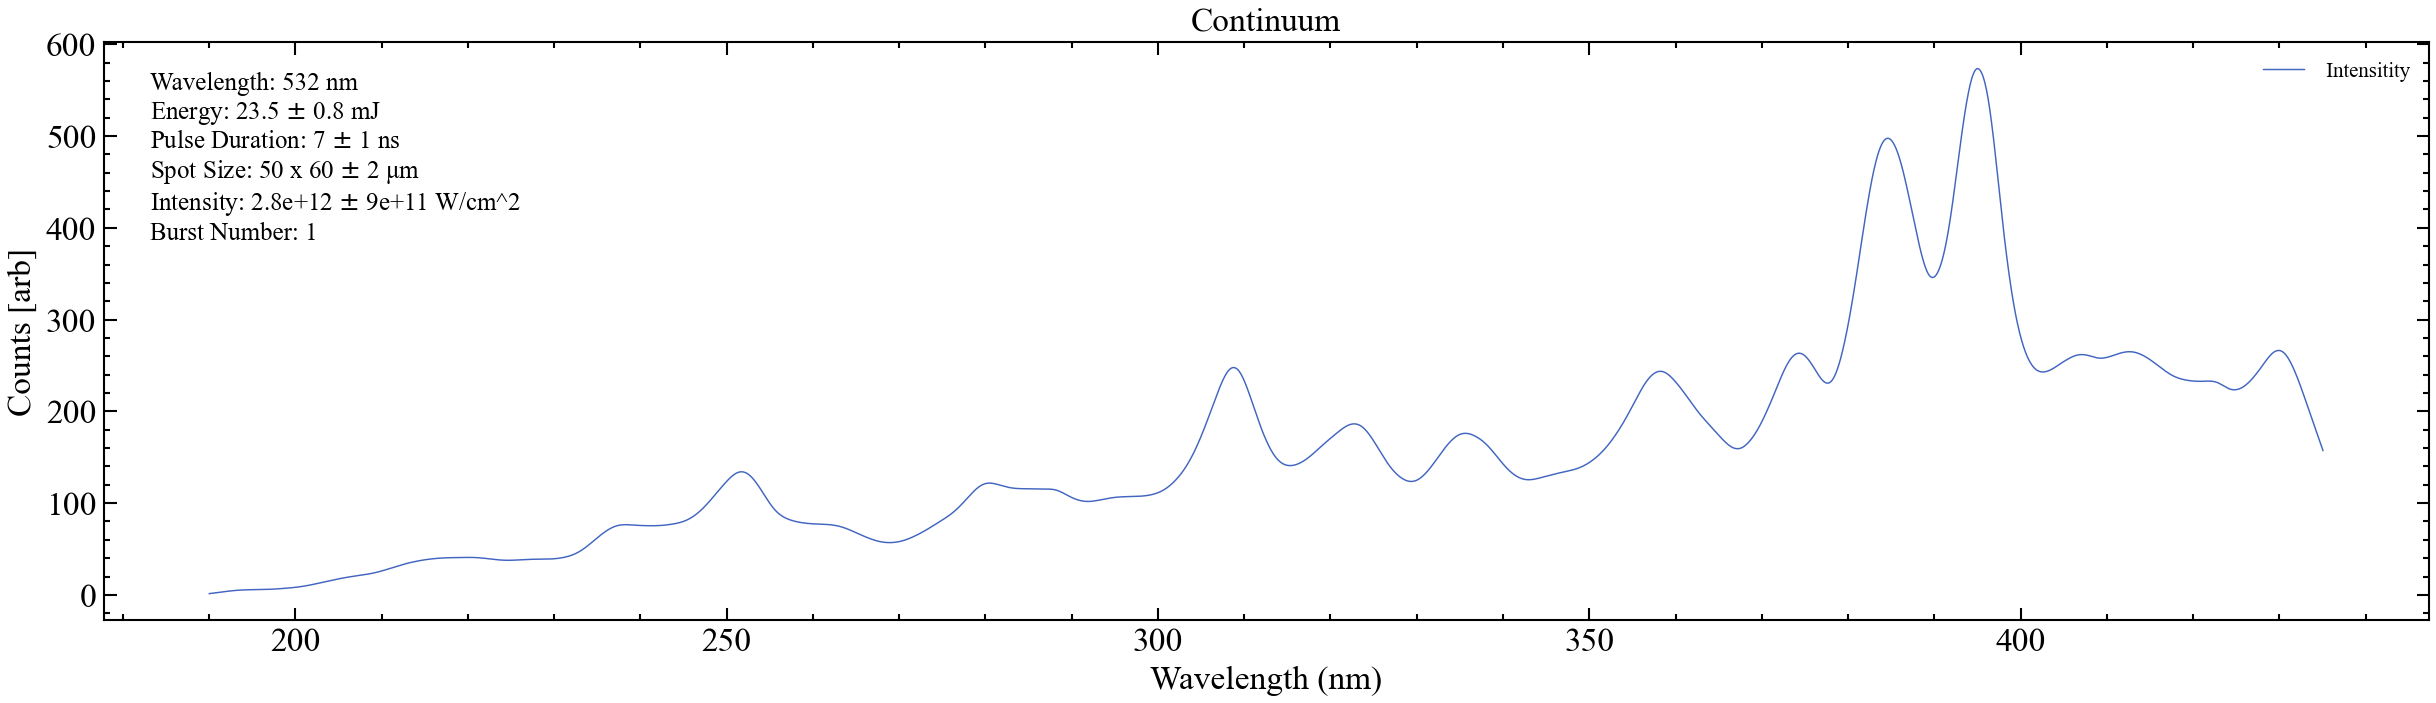

Plotting took 0.4704866409301758 seconds
(3955,) (3955,)
Plotting standard deviation


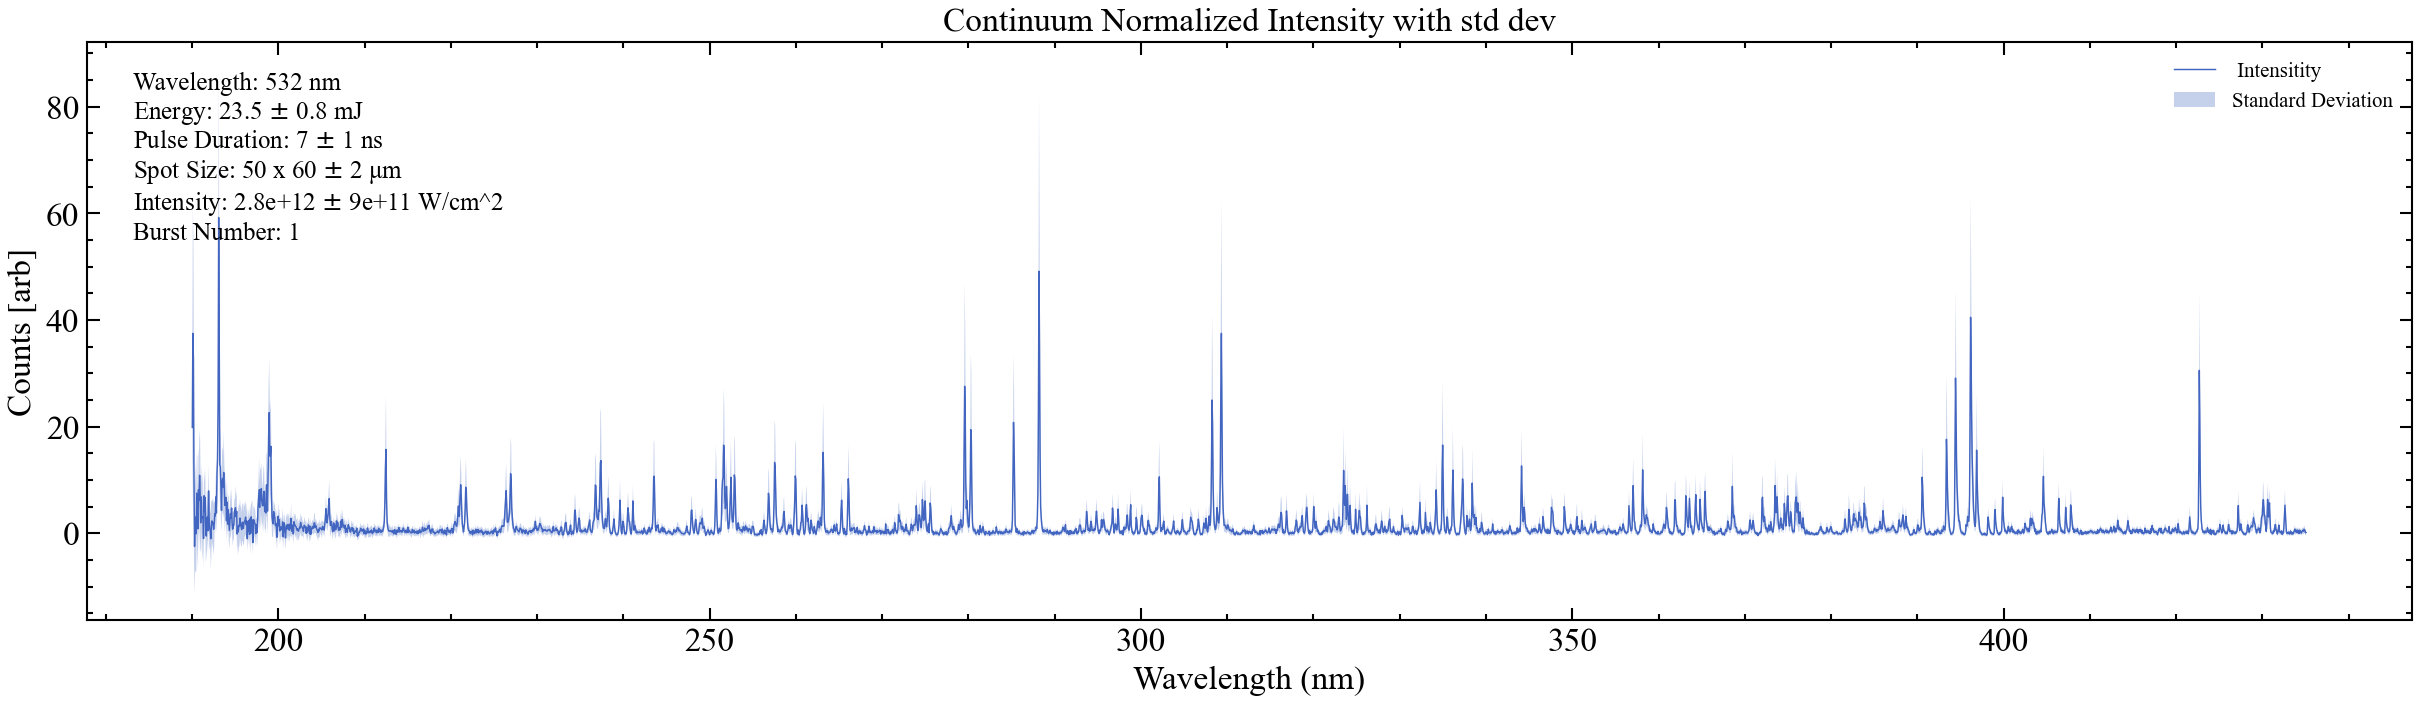

Plotting took 0.8214006423950195 seconds


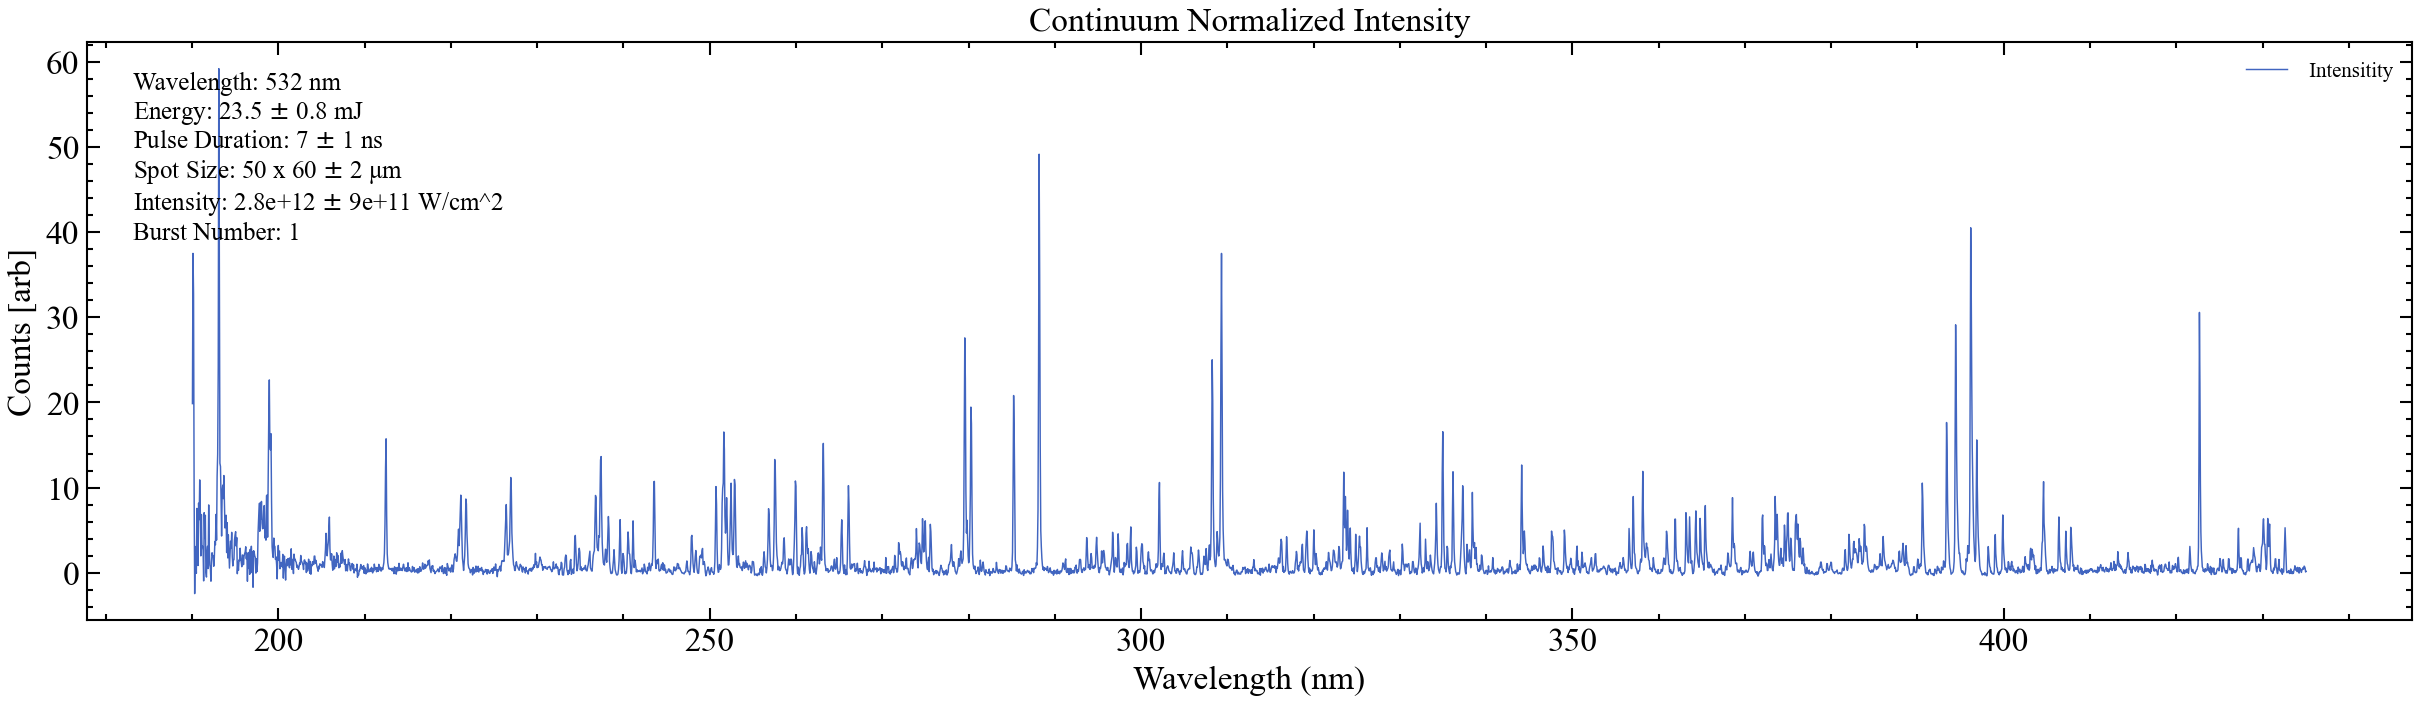

Plotting took 0.4426860809326172 seconds


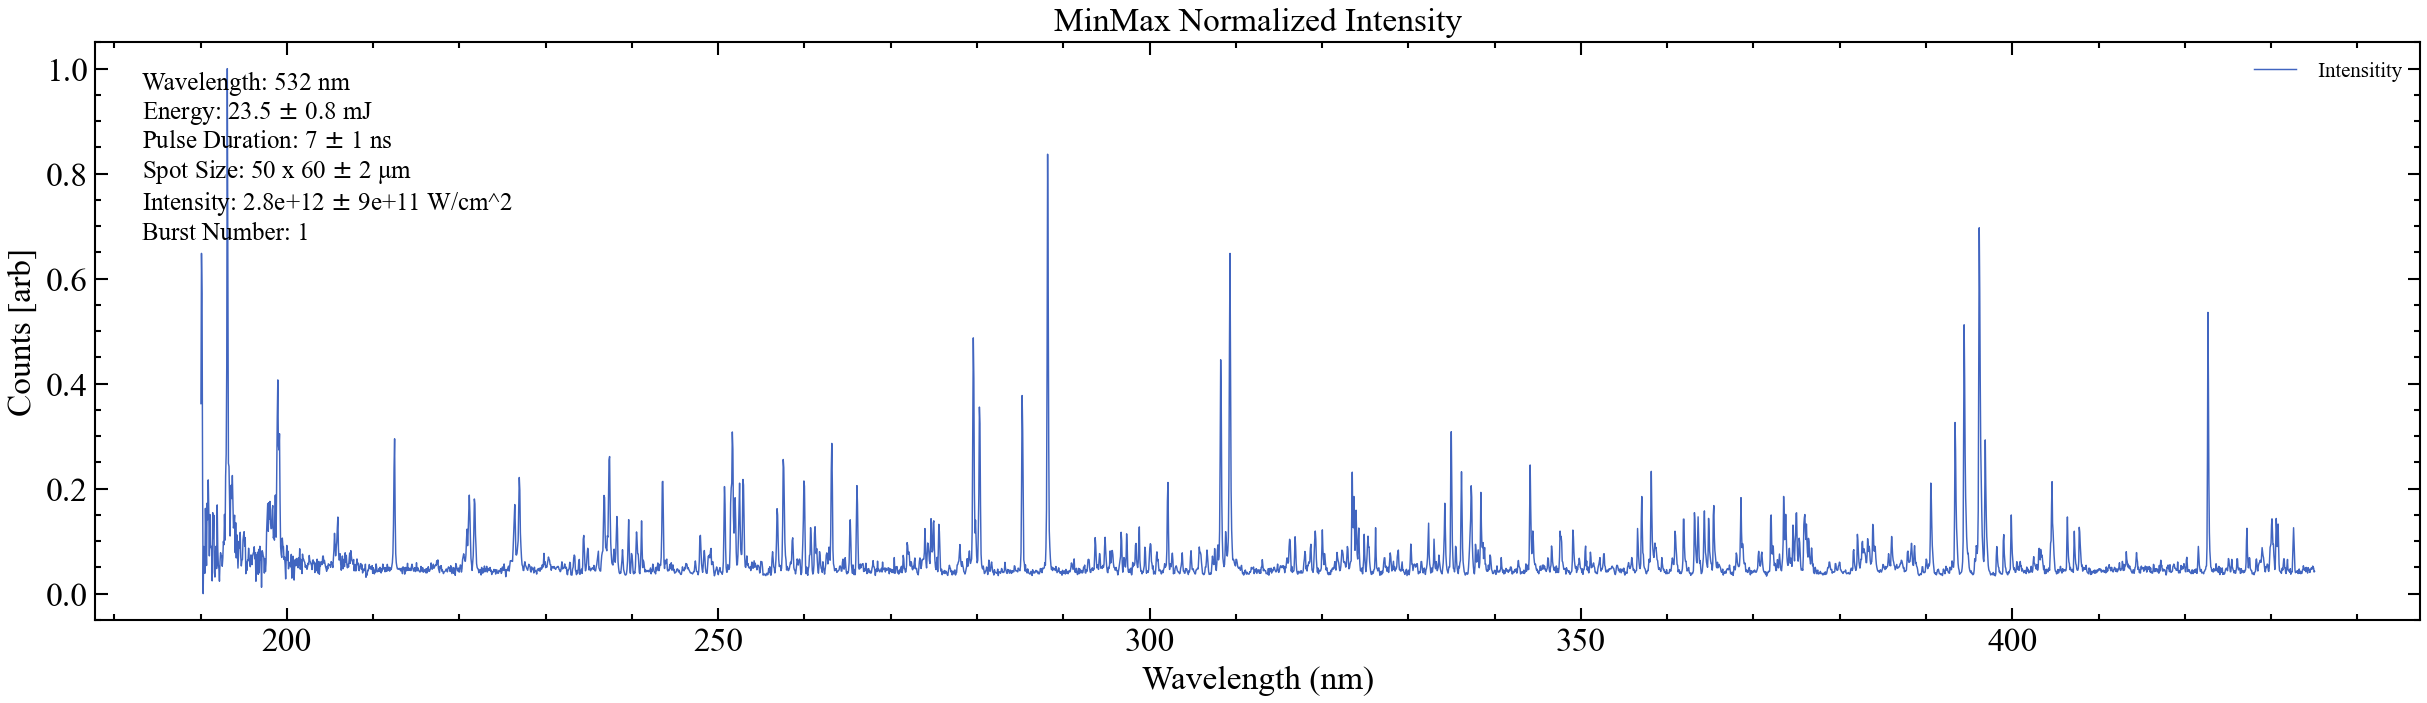

Plotting took 0.41571617126464844 seconds


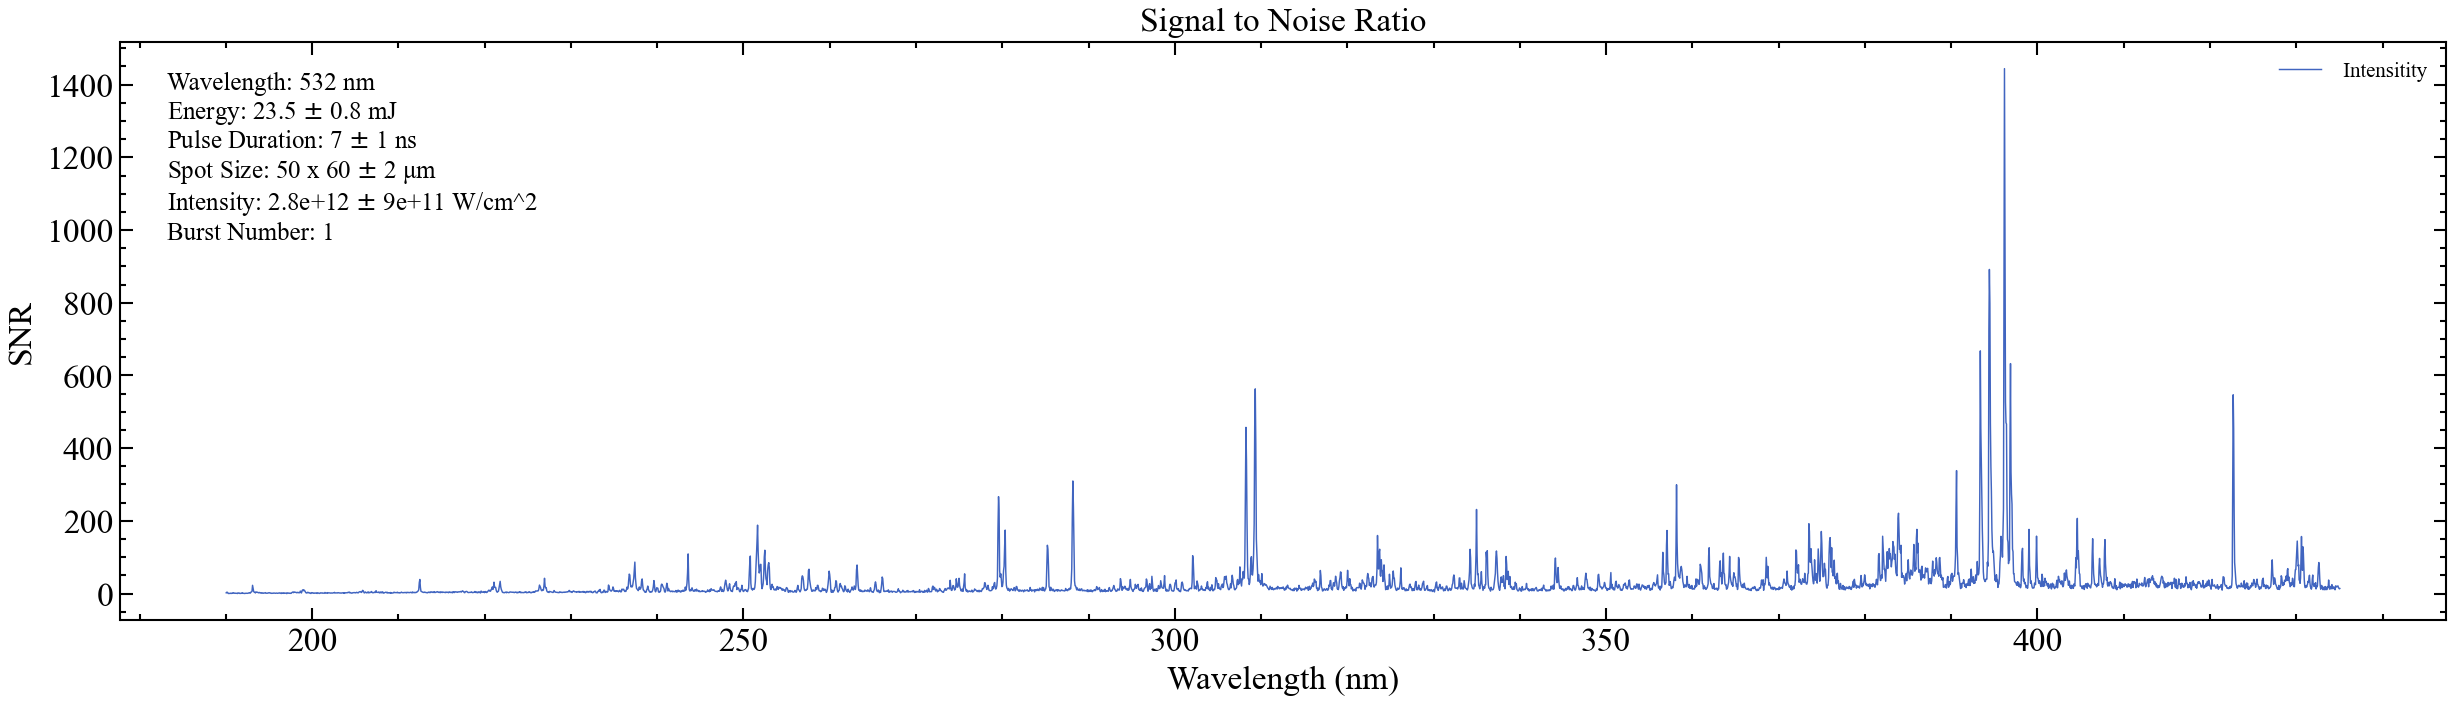

Plotting took 0.5593159198760986 seconds


c:\Users\Liam\Documents\git\portableLIBS\Analysis Software\analysis_db.py:340: RuntimeWarning: invalid value encountered in log10
  plot_spectra_rectangular(wavelength, 10*np.log10(snr), qsdelay=qsdelay, sample_id=sample_id, title="Signal to Noise Ratio, dB", ylabel='SNR [dB]', plot=plot, dpi=dpi, figsize=figsize, font_size=font_size, figdir=figdir, do_save=do_save, bstnum=bstnum, verbose=verbose)


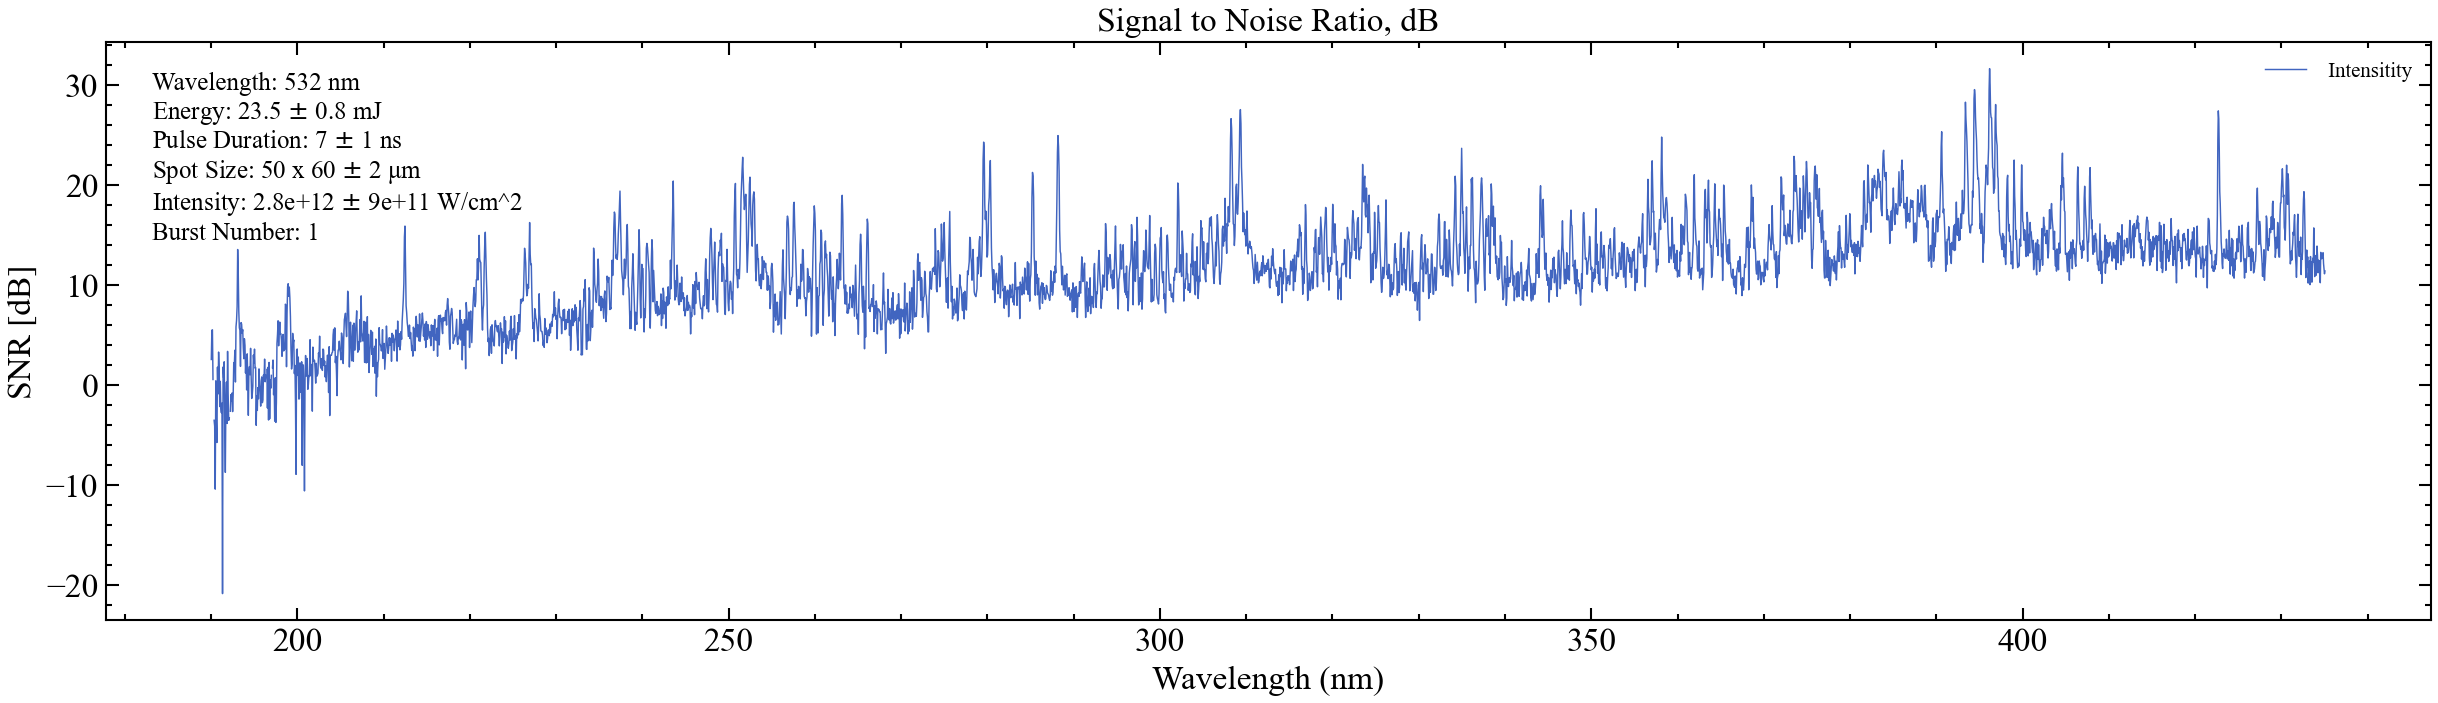

Plotting took 0.5129570960998535 seconds


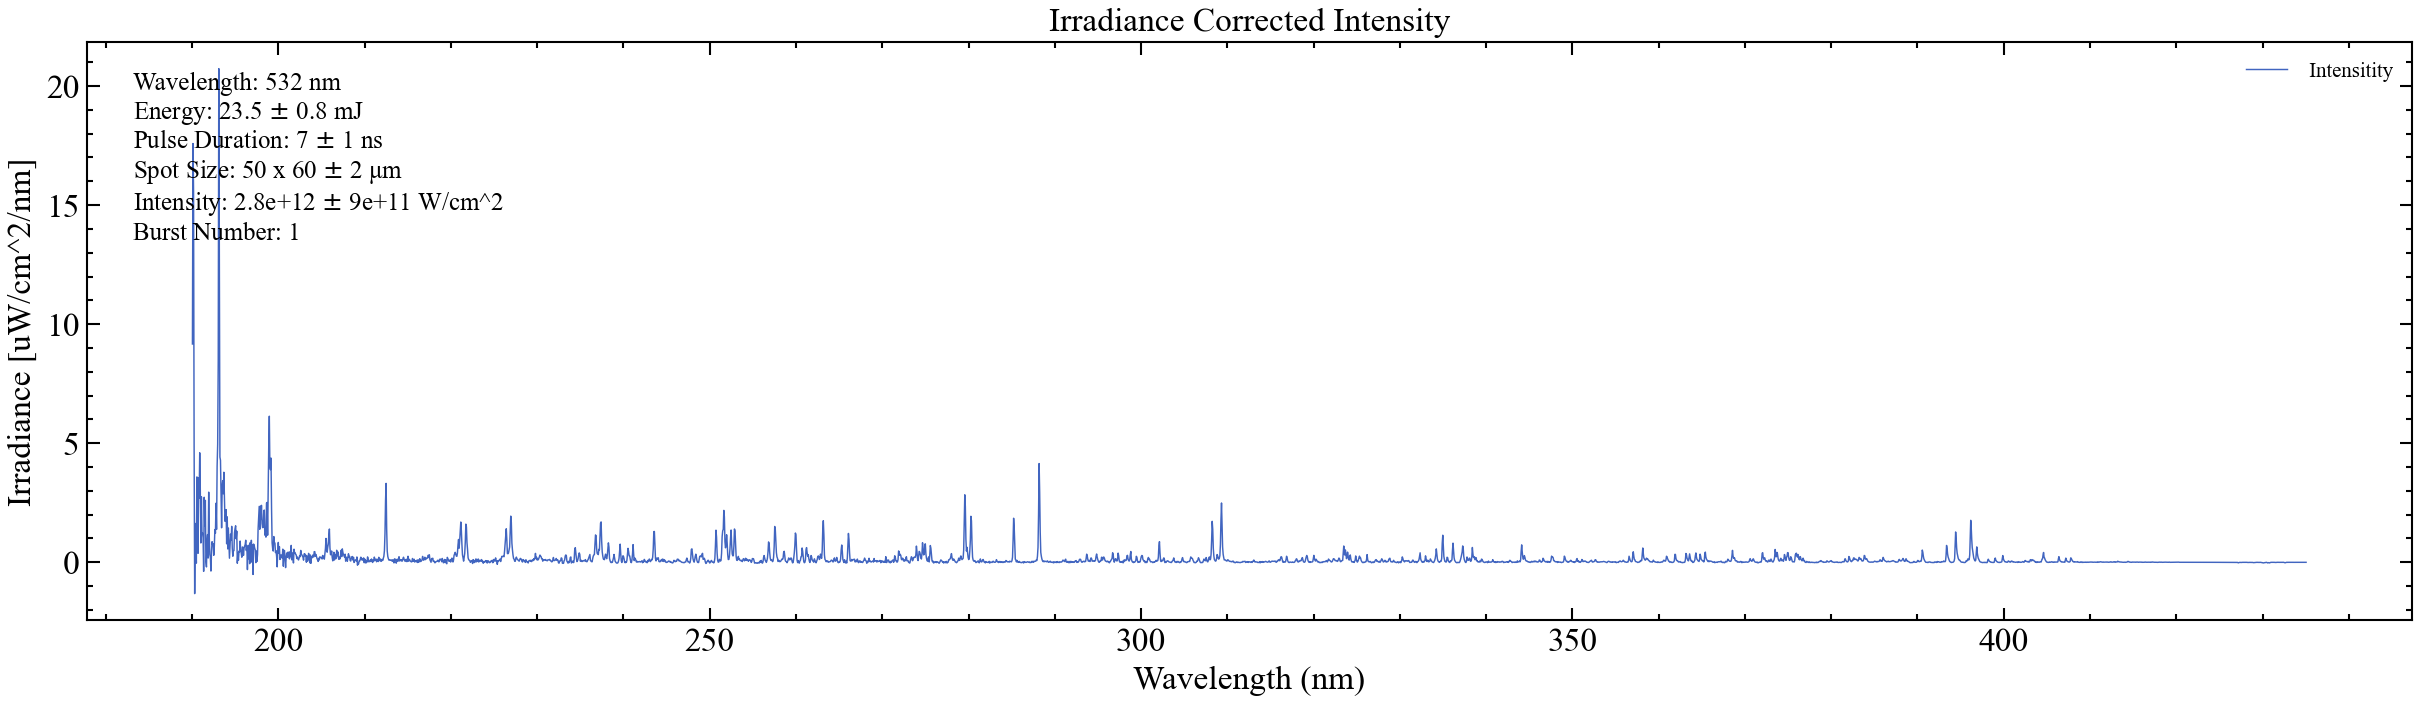

Plotting took 0.5220725536346436 seconds


In [35]:
plot_analyzed_data(cont_h5, figsize=(20, 5), do_save=False, dpi=150, verbose=True)

In [22]:
import h5py

with h5py.File(cont_h5, 'r') as f:
    print(f.keys())
    intensity = f['Intensity'][:]
    irradiance = f['IrradianceCorrectedIntensity'][:]
    wavelength = f['Wavelength'][:]
print(intensity, wavelength)

<KeysViewHDF5 ['Continuum', 'ContinuumNormalized', 'ContinuumNormalizedStd', 'Intensity', 'IrradianceCorrectedIntensity', 'SNR', 'Wavelength', 'minmax_Intensity']>
[19.86093322 37.50974248 32.76392443 ...  0.52717434  0.08290588
  0.16078702] [190.03738815 190.10241346 190.16743917 ... 434.93676982 434.99068439
 435.04459177]


In [7]:
import pandas as pd
lines = r"C:\Users\Liam\Documents\git\portableLIBS\Analysis Software\Identified_lines_Final.xlsx"
lines = pd.read_excel(lines, sheet_name='Sheet1')

In [ ]:
print(lines)

    Atomic Elements  Wavelength (nm)
0              Al I            193.6
1              Al I            199.0
2              Al I            308.2
3              Al I            309.3
4              Al I            394.4
..              ...              ...
123           Si II            236.0
124           Si II            413.1
125           Si II            518.2
126           Si II            519.3
127           Si II            637.1

[128 rows x 2 columns]


<Figure size 3000x750 with 0 Axes>

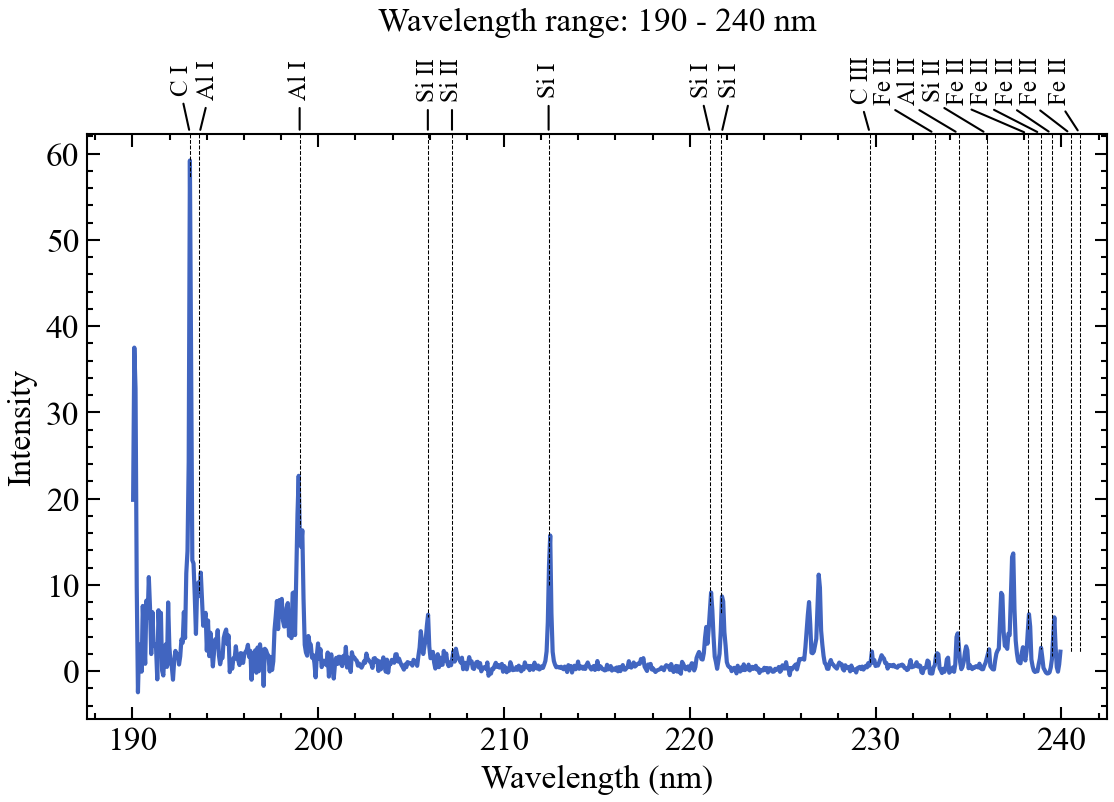

<Figure size 3000x750 with 0 Axes>

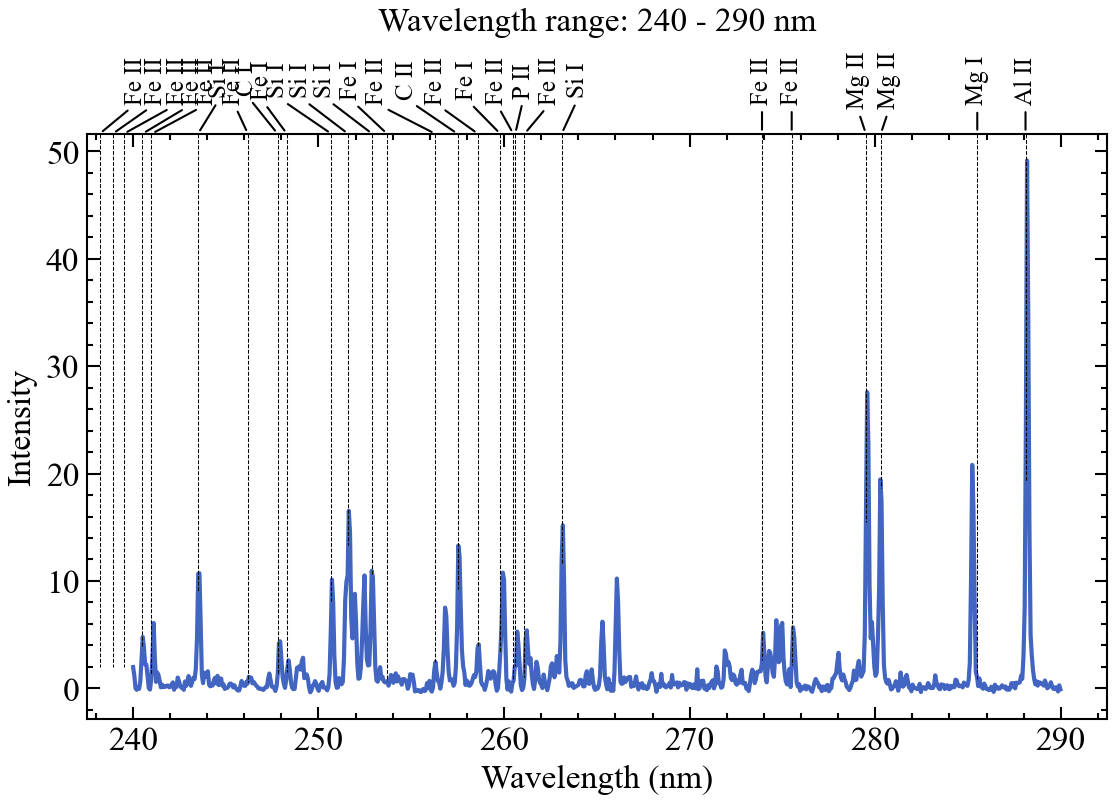

<Figure size 3000x750 with 0 Axes>

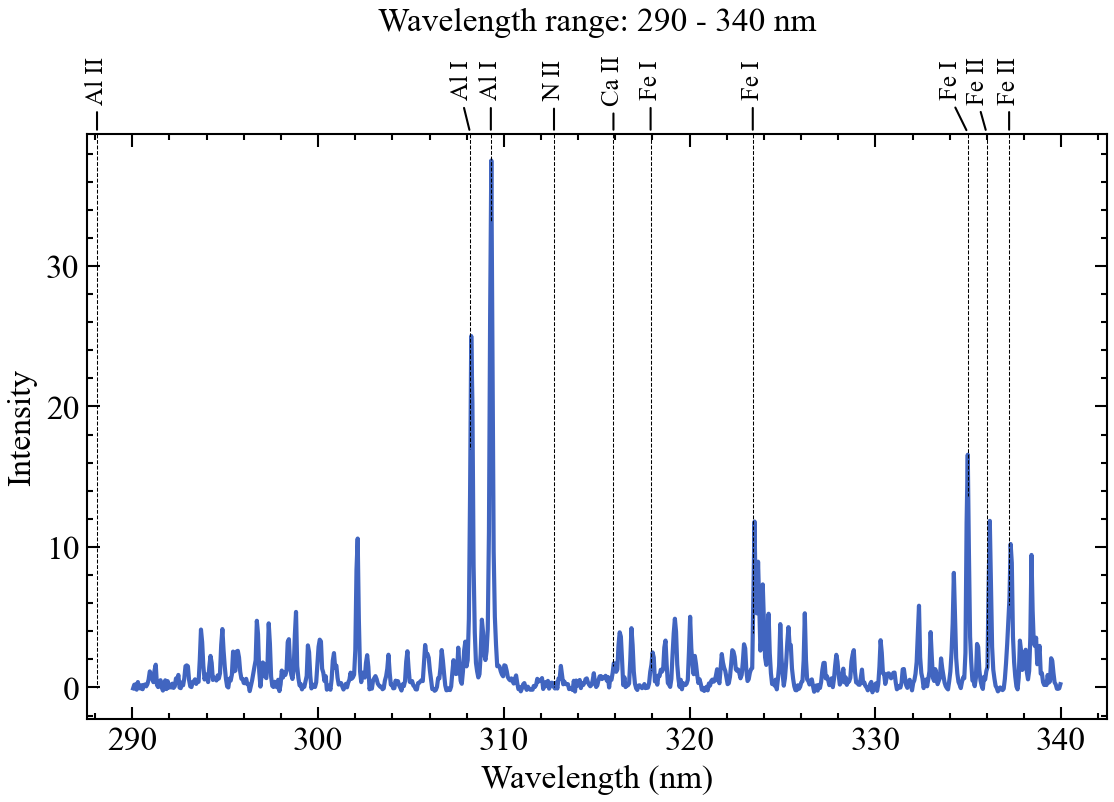

<Figure size 3000x750 with 0 Axes>

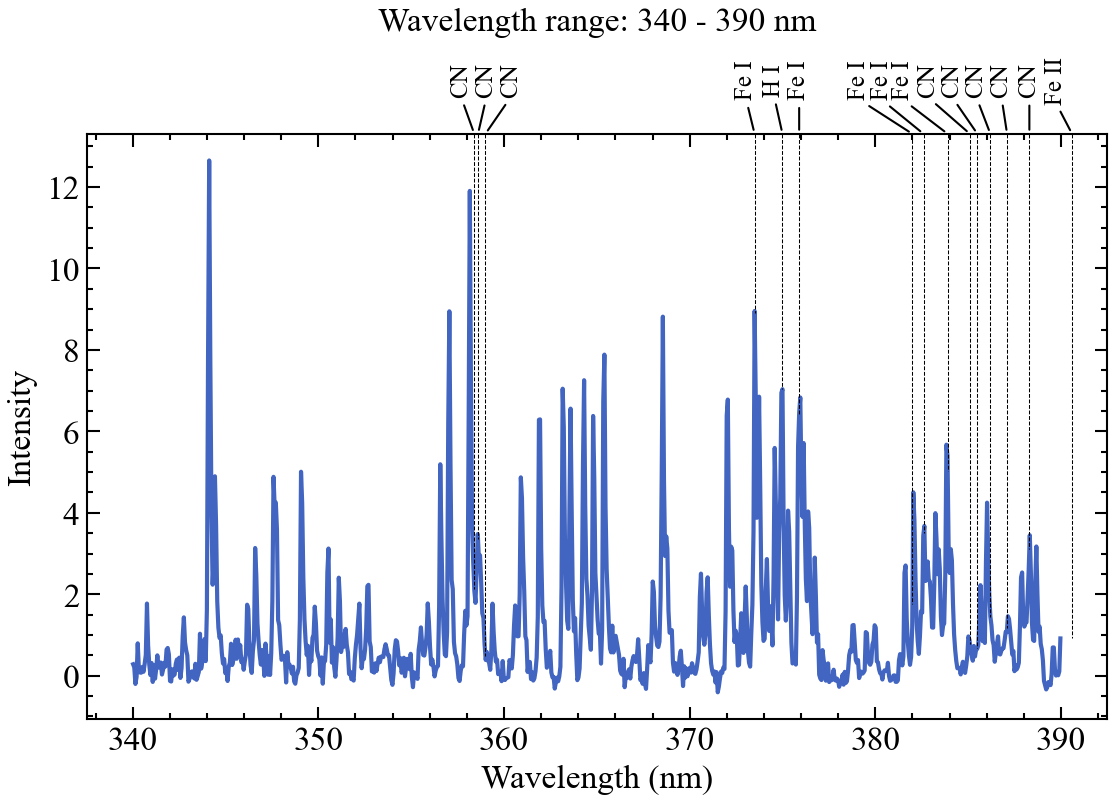

<Figure size 3000x750 with 0 Axes>

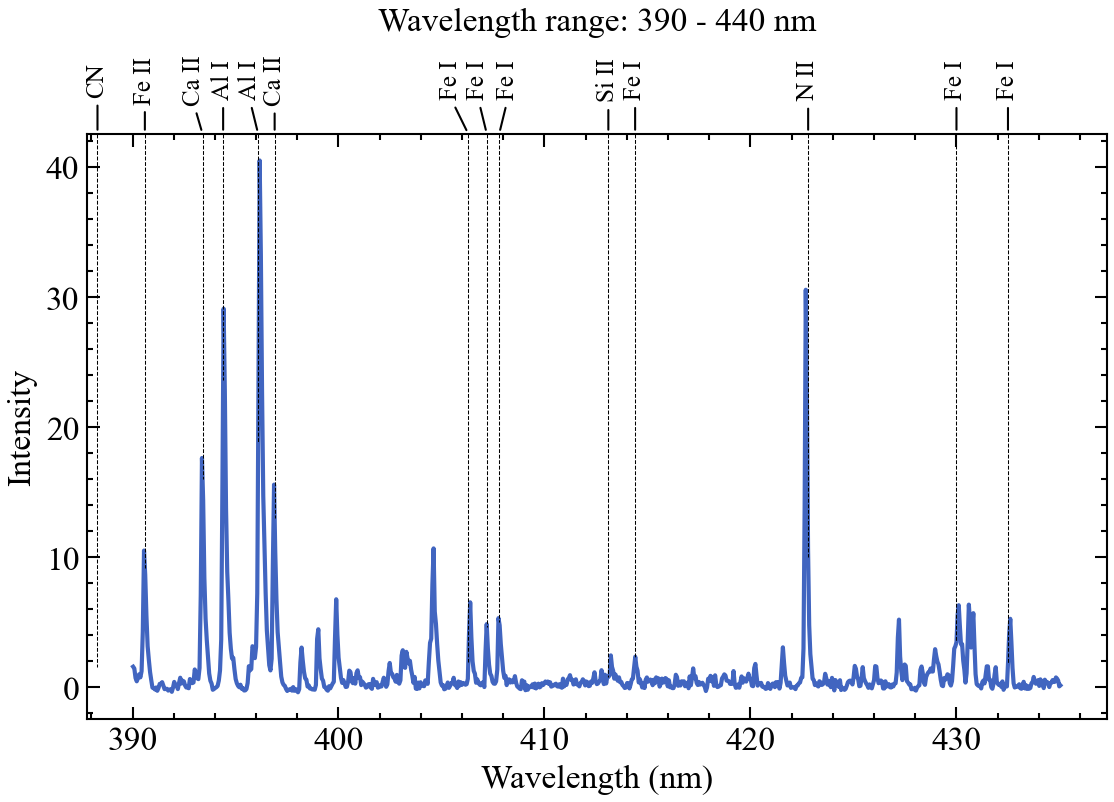

In [ ]:
import lineid_plot as ldplt
import matplotlib.pyplot as plt
wavs = lines['Wavelength (nm)'].values
elems = lines['Atomic Elements'].values
mask = (wavs >= 190) & (wavs <= 435)
wavs = wavs[mask]
elems = elems[mask]
chunks = [(190, 240), (240, 290), (290, 340), (340, 390), (390, 440)]

for start, end in chunks:
    mask_chunk = (wavelength >= start) & (wavelength < end)
    plt.figure(figsize=(20, 5))
    ldplt.plot_line_ids(wavelength[mask_chunk], intensity[mask_chunk], wavs, elems, plot_kwargs={'linewidth': .5})
    plt.title(f'Wavelength range: {start} - {end} nm', pad=50)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Intensity')
    plt.show()

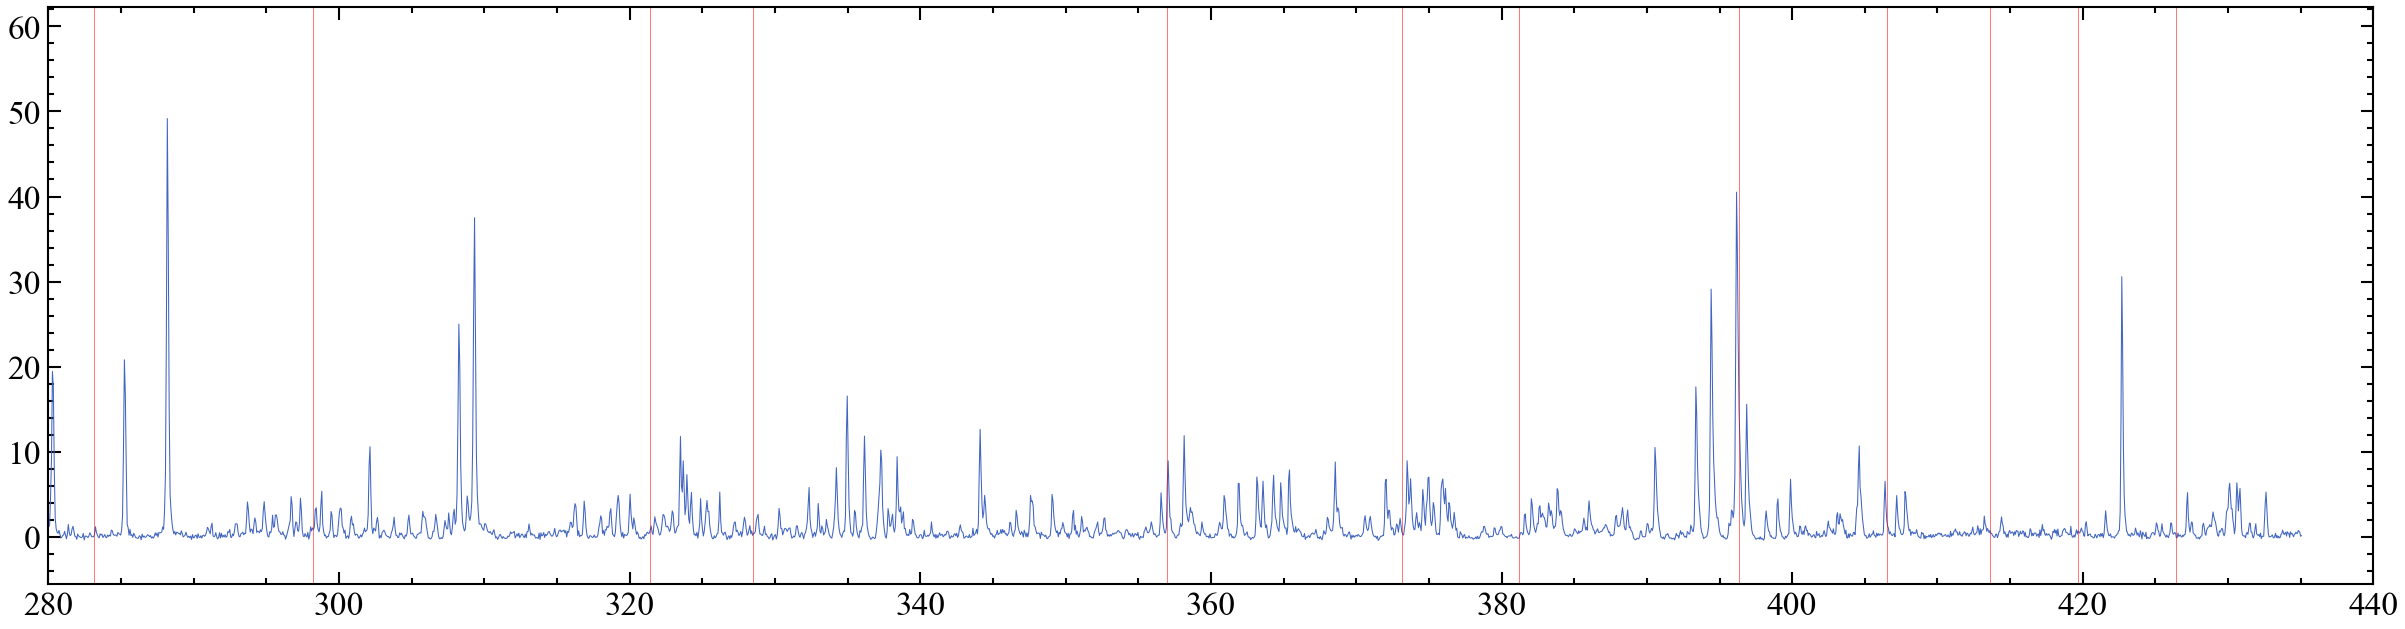

In [25]:
plt.gcf().set_size_inches(20, 5)
plt.xlim(280, 440)
plt.plot(wavelength, intensity, linewidth=0.5)
fe = [283.15, 298.22, 321.37, 328.5, 357, 373.13, 381.18, 396.31, 406.53, 413.62, 419.7, 426.4]
for i in fe:
    plt.axvline(i, color='r', linewidth=0.25)
    



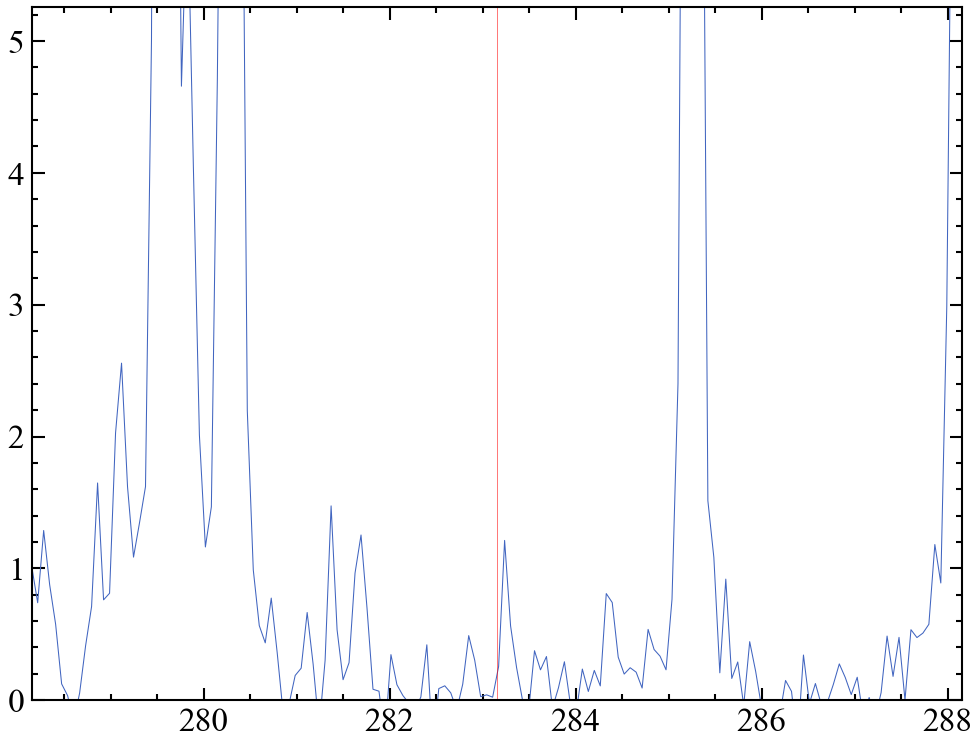

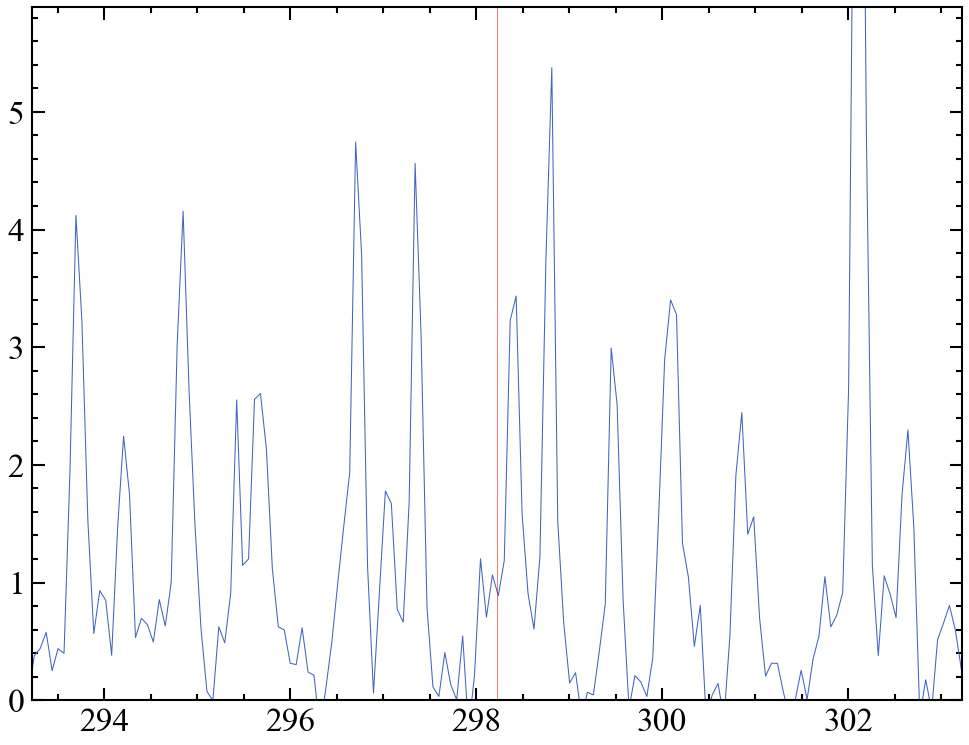

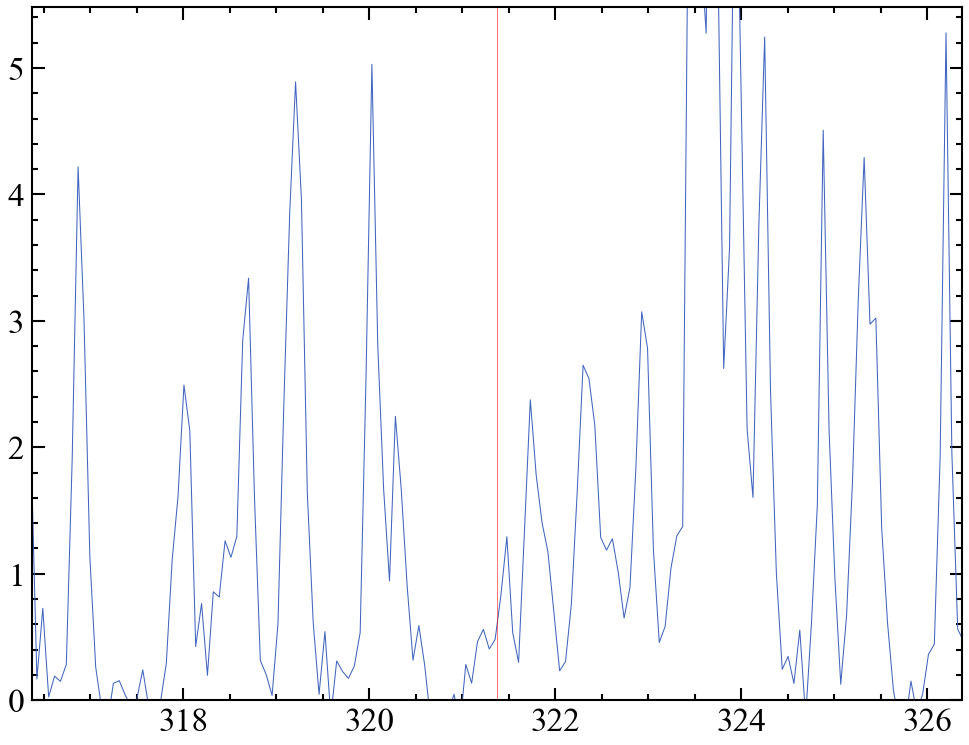

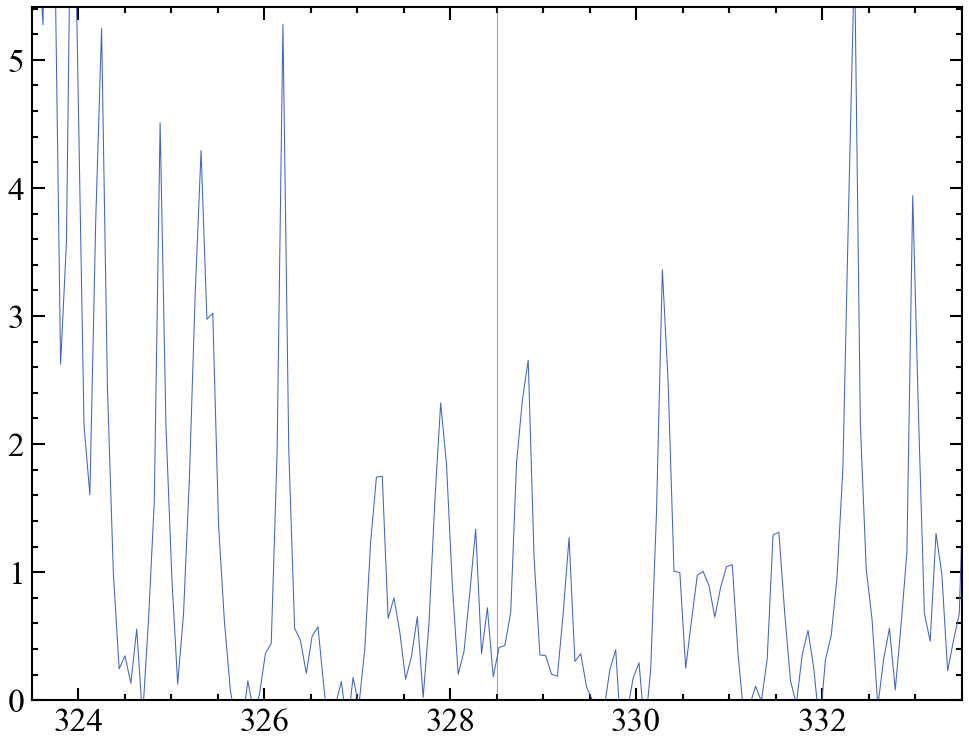

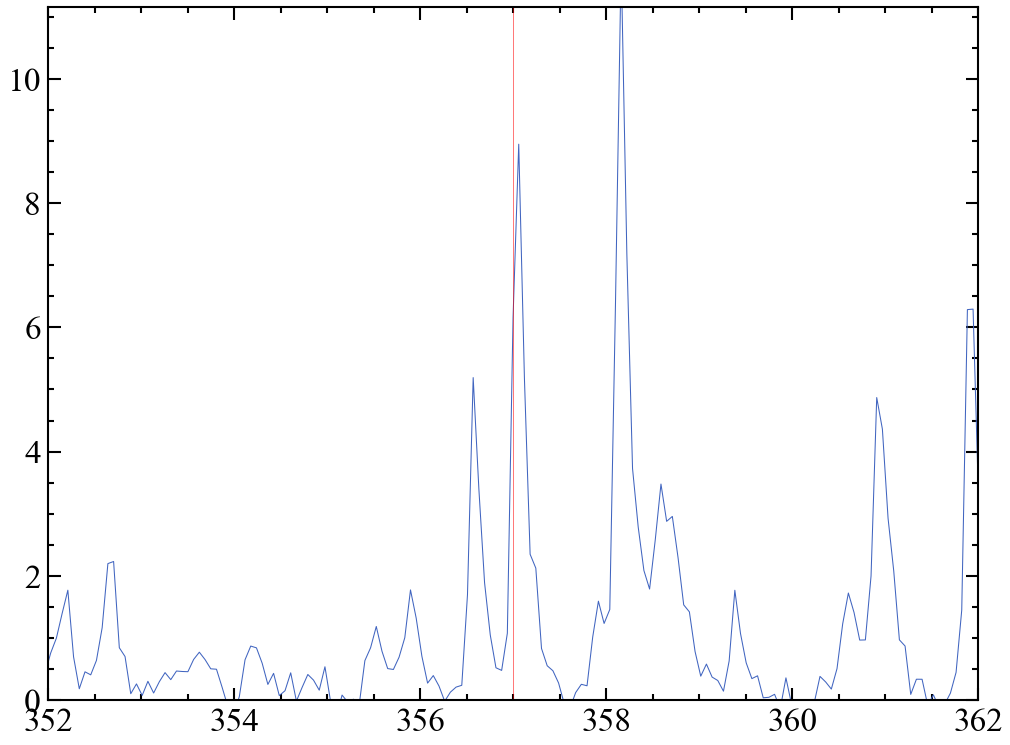

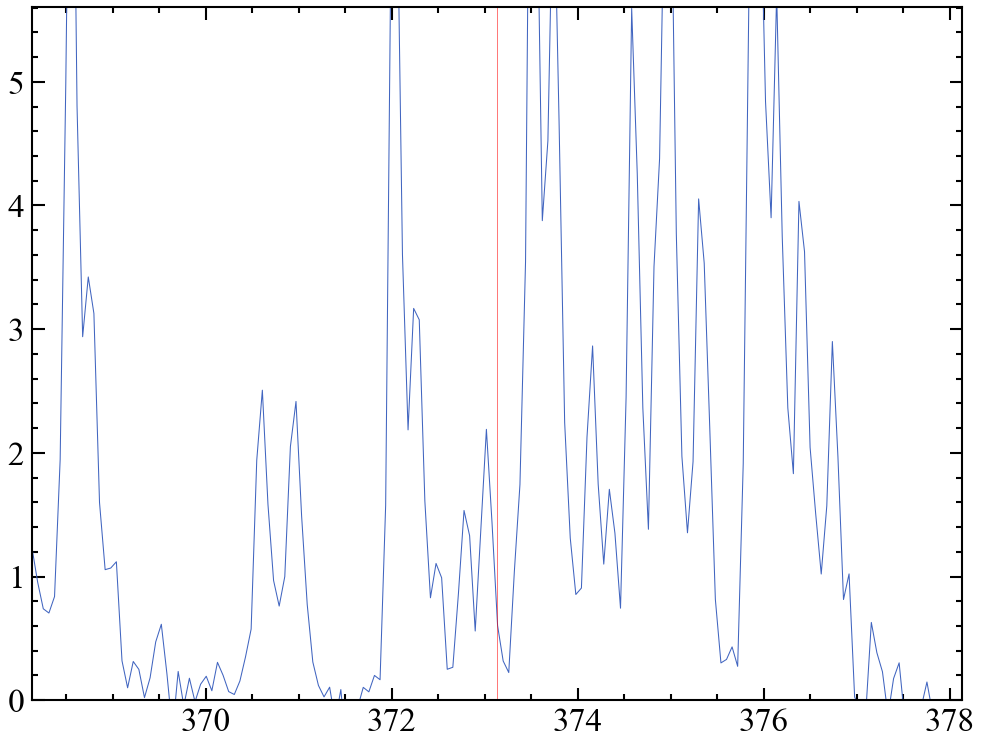

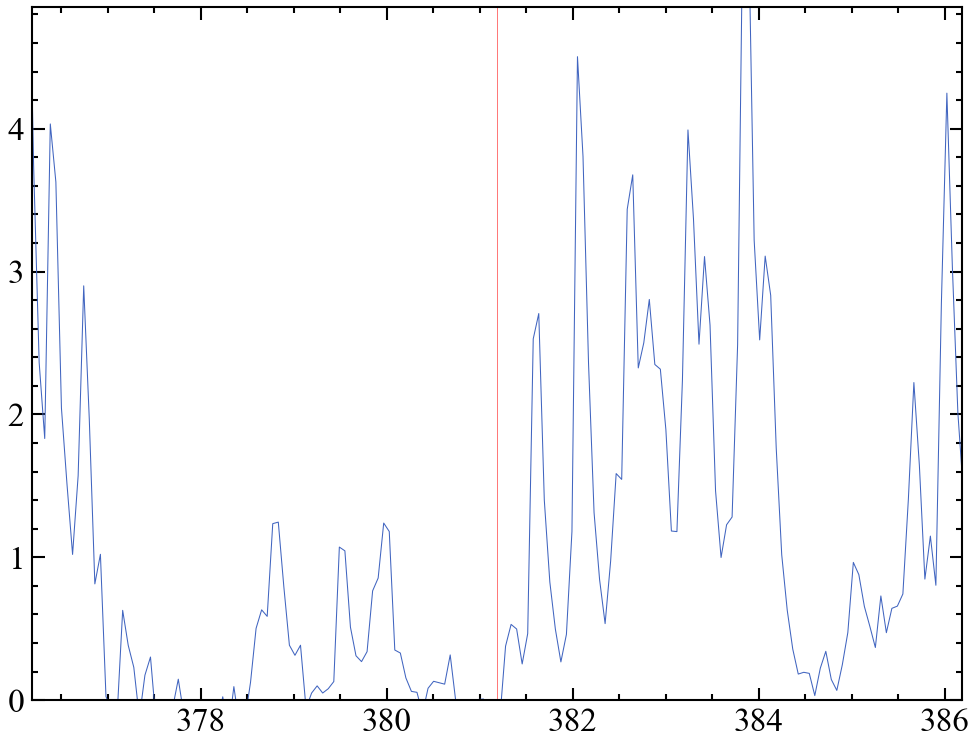

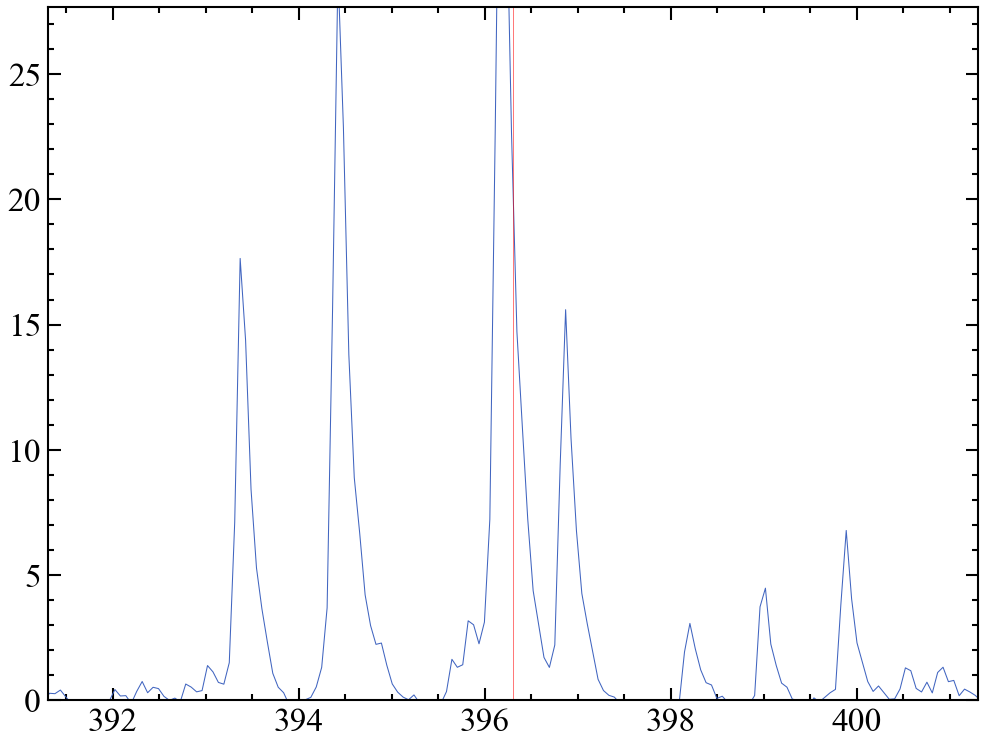

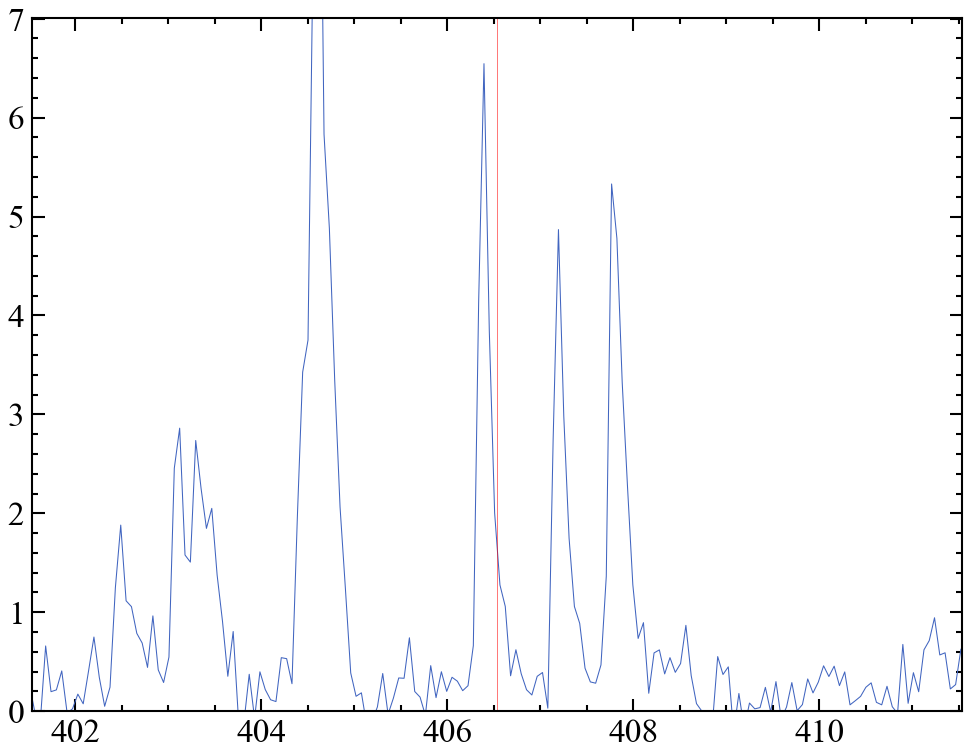

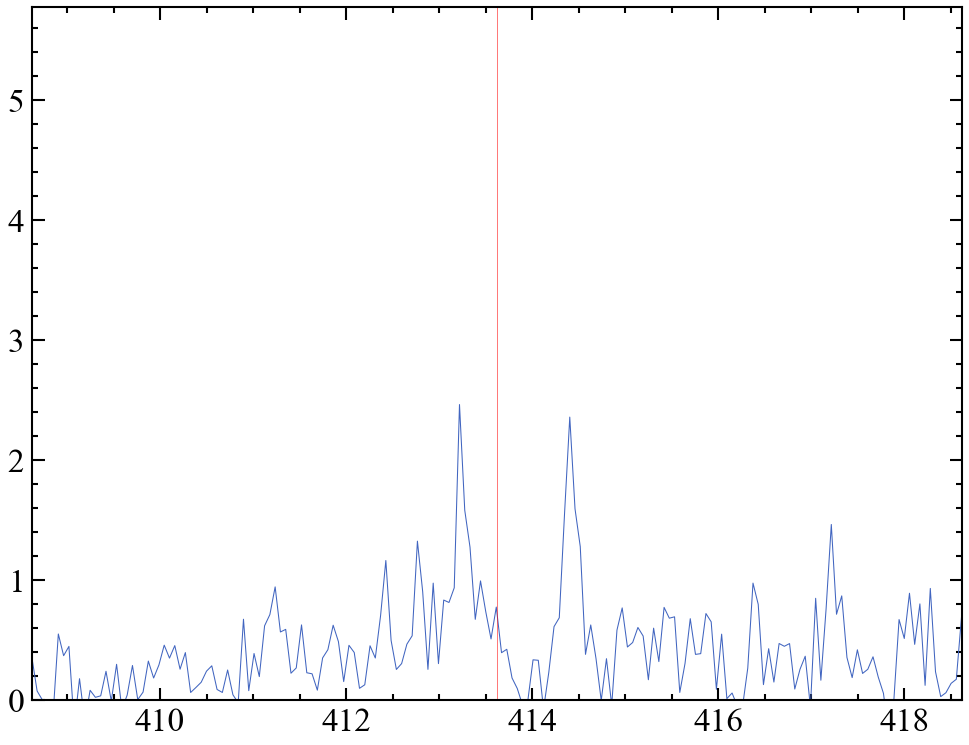

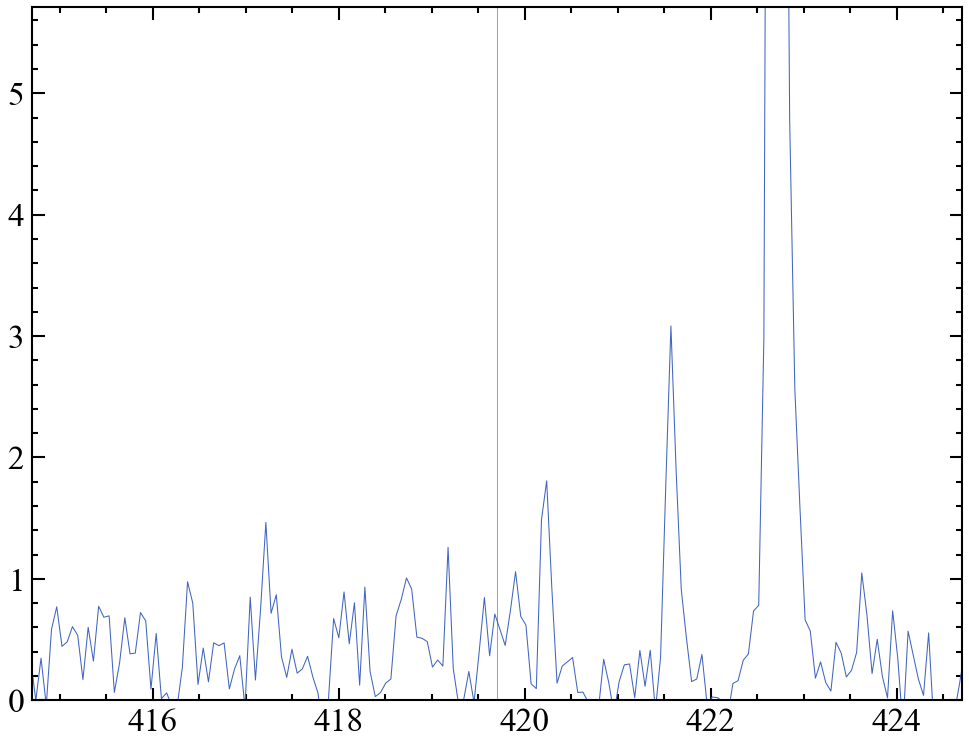

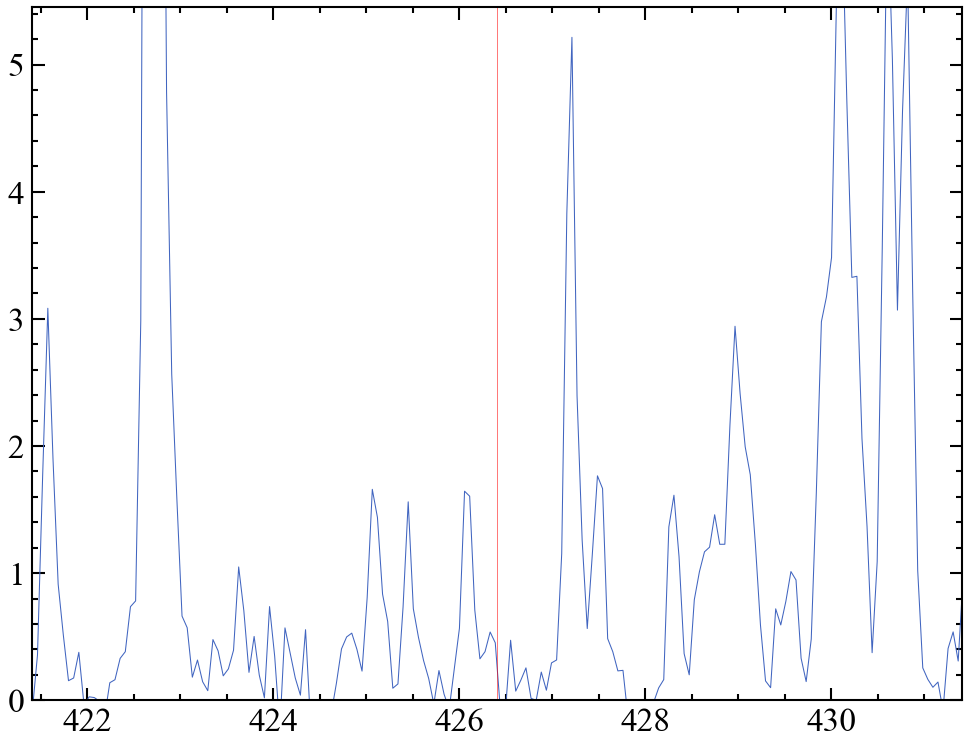

In [34]:
for i in fe:
    plt.xlim(i-5, i+5)
    plt.ylim(0, intensity[np.argmin(np.abs(wavelength - i))] + 5)
    plt.plot(wavelength, intensity, linewidth=0.5)
    plt.axvline(i, color='r', linewidth=0.25)
    plt.show()